<a href="https://colab.research.google.com/github/omarcordero1/-omarcordero1/blob/main/Segmentaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ANÁLISIS DE COBERTURA EDITORIAL MILENIO.COM**
Extracción de Temas, Entidades y Variables Accionables para Periodistas

INSTALACIONES Y LIBRERÍAS

In [ ]:
!pip install pandas numpy scikit-learn spacy transformers torch
!pip install bertopic umap-learn hdbscan
!pip install contractions unidecode
!python -m spacy download es_core_news_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 74.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Librerias a usar

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

Carganos Base de datos

In [ ]:
import pandas as pd
# Carga tu base de datos (copia el archivo a Colab)
from google.colab import files
uploaded = files.upload()  # Sube tu Base_de_trabajo.xlsx

df = pd.read_excel('Base de trabajo.xlsx')
df = df[df.columns[:16]]  # Eliminar columnas vacías

print(f"Dataset cargado: {df.shape[0]} noticias, {df.shape[1]} campos")
print(f"\nPrimeras columnas: {df.columns.tolist()}")

Saving Base de trabajo.xlsx to Base de trabajo.xlsx
Dataset cargado: 13161 noticias, 16 campos

Primeras columnas: ['id', 'tipo', 'titulo', 'URL', 'slug', 'Pv´s', 'Registros', 'seccion', 'editor', 'plaza', 'creacion', 'autor', 'ultima edicion', 'Día de la semana', 'Fecha', 'Hora']


LIMPIEZA Y PREPARACIÓN DE TEXTO

In [ ]:
import re
import contractions
from unidecode import unidecode

def limpiar_texto(texto):
    """Limpia y normaliza texto para análisis"""
    if pd.isna(texto):
        return ""

    # Convertir a minúsculas
    texto = str(texto).lower()

    # Eliminar acentos
    texto = unidecode(texto)

    # Eliminar URLs
    texto = re.sub(r'http\S+|www.\S+', '', texto)

    # Eliminar caracteres especiales
    texto = re.sub(r'[^a-z0-9\s]', '', texto)

    # Eliminar espacios múltiples
    texto = re.sub(r'\s+', ' ', texto).strip()

    return texto

df['texto_limpio'] = df['titulo'].apply(limpiar_texto)

# Combinar título + sección para mejor contexto
df['texto_analisis'] = df['titulo'].astype(str) + ' ' + df['seccion'].fillna('').astype(str)
df['texto_analisis'] = df['texto_analisis'].apply(limpiar_texto)

print("✓ Textos limpios")

✓ Textos limpios


VARIABLE 1 - TEMAS (CLUSTERIZACIÓN CON BERTopic)


In [ ]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

# Configurar vectorizador en español
spanish_stop_words = ["el", "la", "de", "que", "y", "a", "en", "es", "se", "los", "las",
                      "del", "por", "con", "un", "una", "os", "fue", "han", "pero"]

vectorizer_model = CountVectorizer(max_df=0.95, min_df=2, # Increased max_df to 0.95 to be less restrictive
                                   stop_words=spanish_stop_words,
                                   ngram_range=(1, 2))

# Entrenar BERTopic (usa embeddings multilingües)
topic_model = BERTopic(language="spanish",
                       vectorizer_model=vectorizer_model,
                       top_n_words=10,
                       min_topic_size=30)

topics, probs = topic_model.fit_transform(df['texto_analisis'].tolist())

df['tema_id'] = topics
df['tema_probabilidad'] = probs

# Mapear IDs de temas a etiquetas legibles
tema_labels = {}
for topic_id in df['tema_id'].unique():
    if topic_id != -1:  # -1 son outliers
        words = topic_model.get_topic(topic_id)
        top_words = [word for word, score in words[:3]]
        tema_labels[topic_id] = ' + '.join(top_words)

df['tema'] = df['tema_id'].map(tema_labels).fillna('Otro')

print(f"\n✓ Temas identificados: {len(tema_labels)} clusters")
print("\nDistribución de temas (Top 10):")
print(df['tema'].value_counts().head(10))

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


✓ Temas identificados: 58 clusters

Distribución de temas (Top 10):
tema
Otro                                             4395
policia + hombre + detienen                      1470
politica + morena + sheinbaum                    1055
negocios + mexico + inversion                     651
liga mx + mx + liga                               486
futbol + futbol internacional + internacional     351
musica + concierto + boletos                      325
cine + television + netflix                       292
operaciones + grilla + tremenda                   251
cdmx + comunidad + tren                           225
Name: count, dtype: int64


VARIABLE 2 - ENTIDADES/PERSONAJES (NER CON SPACY)


In [ ]:
import spacy

nlp = spacy.load('es_core_news_sm')

def extraer_entidades(texto):
    """Extrae personajes e instituciones principales"""
    if pd.isna(texto) or len(str(texto)) < 5:
        return "No identificado"

    doc = nlp(str(texto)[:500])  # Limitar a 500 caracteres por velocidad

    # Filtrar entidades: PERSON, ORG, MISC
    entidades = [ent.text for ent in doc.ents
                 if ent.label_ in ['PERSON', 'ORG', 'MISC', 'LOC']]

    if not entidades:
        return "No identificado"

    # Retornar la entidad más frecuente (la principal)
    from collections import Counter
    principal = Counter(entidades).most_common(1)[0][0]

    return principal

print("\nExtrayendo entidades principales...")
df['personaje_principal'] = df['titulo'].apply(extraer_entidades)

print(f"✓ Personajes/Entidades extraídos")
print("\nTop 15 actores principales:")
print(df['personaje_principal'].value_counts().head(15))


Extrayendo entidades principales...
✓ Personajes/Entidades extraídos

Top 15 actores principales:
personaje_principal
No identificado    2046
México              299
EU                  201
Tamaulipas          128
Qué                 128
Monterrey           127
¿Cómo               126
Edomex              106
¿Quién              103
Coahuila            101
Puebla               96
Nuevo León           89
Jalisco              88
Torreón              84
CdMx                 77
Name: count, dtype: int64


VARIABLE 3 - ÁREA DE IMPACTO (ACCIONABLE PARA PERIODISTAS)


In [ ]:
def calcular_area_impacto(row):
    """
    Propone áreas de impacto accionables para decisiones editoriales
    Basado en: temas + sección + engagement
    """

    secciones_criticas = ['Política', 'Policía', 'Economía', 'Estados']
    tema = str(row['tema']).lower()
    pv = row['Pv´s']
    seccion = str(row['seccion'])

    # Lógica de clasificación
    if seccion in secciones_criticas:
        if pv > 5000:
            return "CRÍTICO - Alto Impacto"
        else:
            return "CRÍTICO - Bajo Impacto"

    elif any(palabra in tema for palabra in ['deportes', 'futbol', 'juego']):
        if pv > 3000:
            return "ENTRETENIMIENTO - Viral"
        else:
            return "ENTRETENIMIENTO - Nicho"

    elif any(palabra in tema for palabra in ['economía', 'mercado', 'empresa']):
        return "NEGOCIOS - B2B Focus"

    elif any(palabra in tema for palabra in ['comunidad', 'sociedad', 'cultura']):
        if pv > 2000:
            return "SOCIAL - Tendencia"
        else:
            return "SOCIAL - Comunidad Local"

    else:
        if pv > 1500:
            return "GENERAL - Destacable"
        else:
            return "GENERAL - Regularidad"

df['area_impacto'] = df.apply(calcular_area_impacto, axis=1)

print(f"\n✓ Áreas de impacto calculadas")
print("\nDistribución de áreas de impacto:")
print(df['area_impacto'].value_counts())




✓ Áreas de impacto calculadas

Distribución de áreas de impacto:
area_impacto
GENERAL - Regularidad       6558
CRÍTICO - Bajo Impacto      3973
GENERAL - Destacable        1519
ENTRETENIMIENTO - Nicho      407
CRÍTICO - Alto Impacto       292
SOCIAL - Comunidad Local     289
SOCIAL - Tendencia            98
ENTRETENIMIENTO - Viral       25
Name: count, dtype: int64


ANÁLISIS EXPLORATORIO Y VISUALIZACIONES


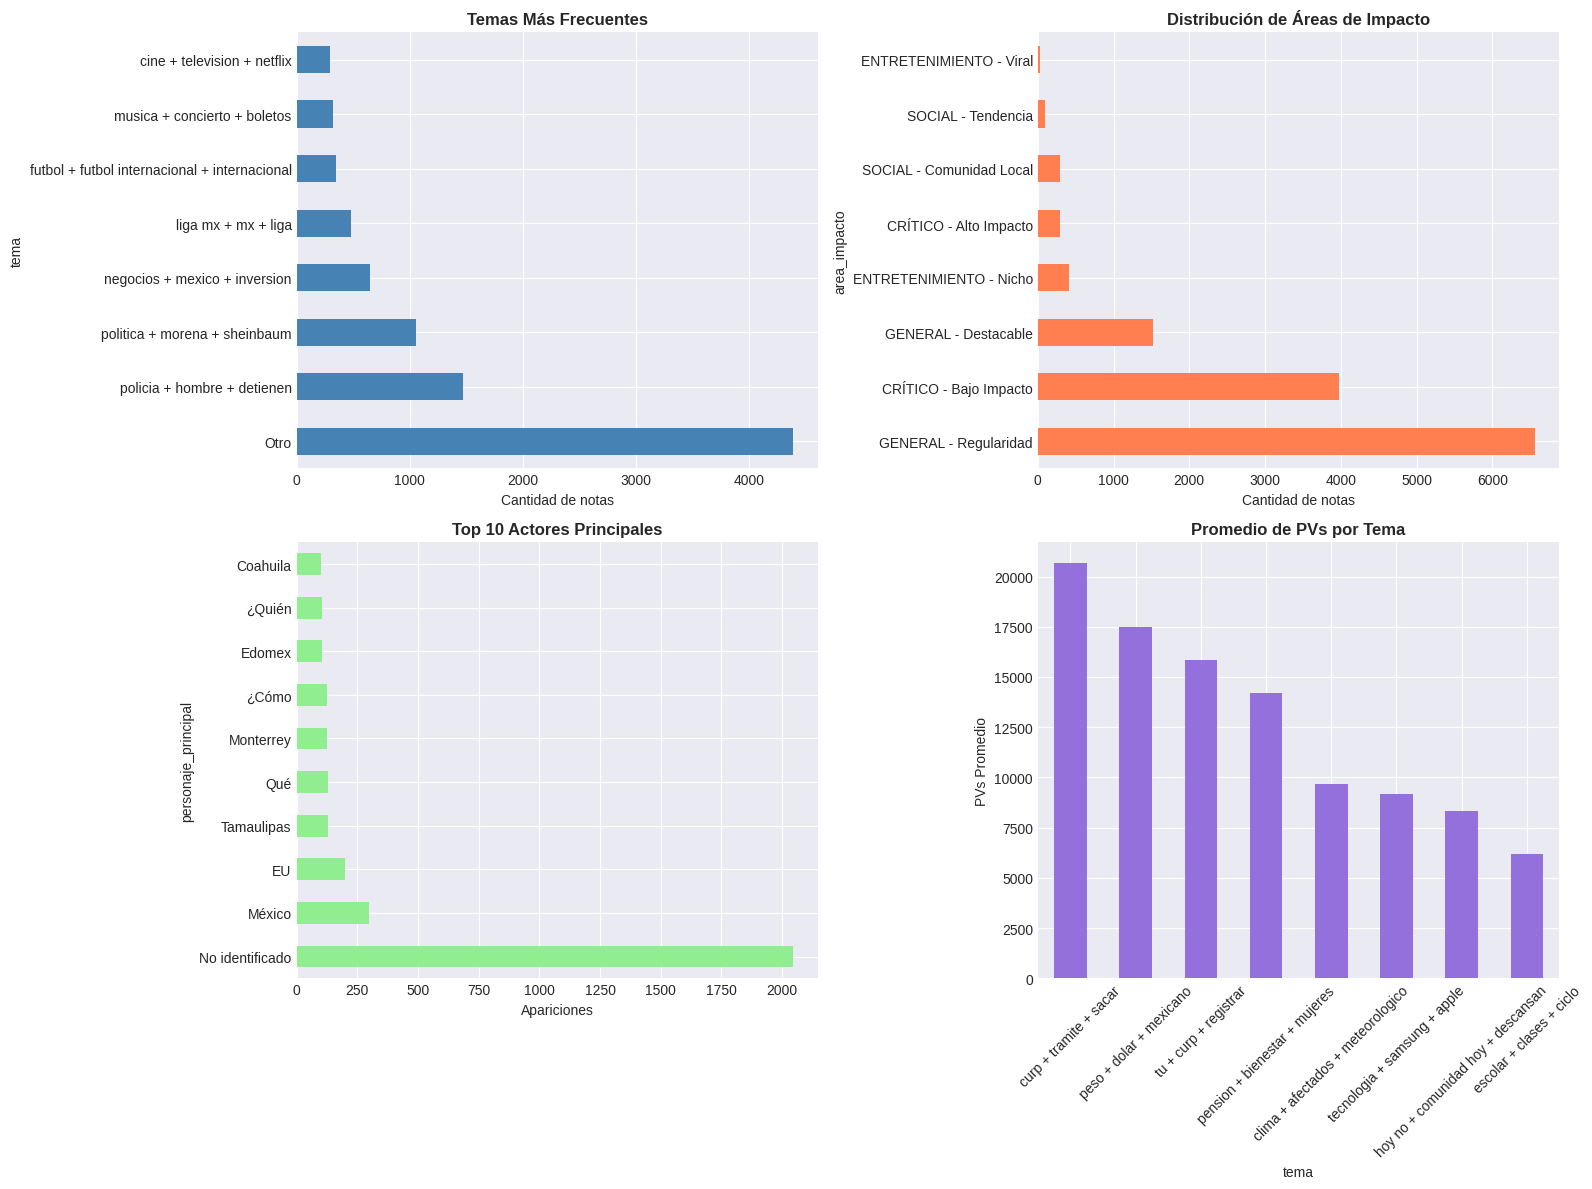

✓ Visualizaciones generadas


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico 1: Temas top
df['tema'].value_counts().head(8).plot(kind='barh', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Temas Más Frecuentes', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Cantidad de notas')

# Gráfico 2: Área de impacto
df['area_impacto'].value_counts().plot(kind='barh', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Distribución de Áreas de Impacto', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Cantidad de notas')

# Gráfico 3: Personajes principales top
df['personaje_principal'].value_counts().head(10).plot(kind='barh', ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Top 10 Actores Principales', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Apariciones')

# Gráfico 4: Engagement por tema
tema_engagement = df.groupby('tema')['Pv´s'].mean().sort_values(ascending=False).head(8)
tema_engagement.plot(kind='bar', ax=axes[1, 1], color='mediumpurple')
axes[1, 1].set_title('Promedio de PVs por Tema', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('PVs Promedio')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('analisis_editorial.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualizaciones generadas")


MATRIX DE RECOMENDACIONES PARA PERIODISTAS

In [ ]:
recomendaciones = pd.DataFrame({
    'Tema': df['tema'].unique()[:10],
    'Frecuencia': [df[df['tema'] == t].shape[0] for t in df['tema'].unique()[:10]],
    'Engagement_Promedio': [df[df['tema'] == t]['Pv´s'].mean() for t in df['tema'].unique()[:10]],
    'Personaje_Principal': [df[df['tema'] == t]['personaje_principal'].mode().values[0]
                             if len(df[df['tema'] == t]) > 0 else 'N/A'
                             for t in df['tema'].unique()[:10]]
})

recomendaciones = recomendaciones.sort_values('Engagement_Promedio', ascending=False)
recomendaciones['Recomendacion'] = recomendaciones.apply(
    lambda x: f"PROFUNDIZAR: {x['Tema']} (especialmente con {x['Personaje_Principal']})"
    if x['Engagement_Promedio'] > df['Pv´s'].mean()
    else f"MONITOREAR: {x['Tema']}", axis=1
)

print("\n" + "="*80)
print("MATRIZ DE RECOMENDACIONES PARA LA REDACCIÓN")
print("="*80)
print(recomendaciones.to_string(index=False))


MATRIZ DE RECOMENDACIONES PARA LA REDACCIÓN
                                         Tema  Frecuencia  Engagement_Promedio Personaje_Principal                                                           Recomendacion
                          liga mx + mx + liga         486          5582.927984           Cruz Azul          PROFUNDIZAR: liga mx + mx + liga (especialmente con Cruz Azul)
                  mansion vip + vip + mansion          31          2439.096774          La Mansión PROFUNDIZAR: mansion vip + vip + mansion (especialmente con La Mansión)
                  policia + hombre + detienen        1470          2027.844898     No identificado                                 MONITOREAR: policia + hombre + detienen
                                         Otro        4395          1831.633447     No identificado                                                        MONITOREAR: Otro
            aguilar + angela aguilar + angela          69          1442.101449     No identificado  

EXPORTAR RESULTADOS


In [ ]:
df_final = df[[
    'id', 'titulo', 'URL', 'editor', 'plaza', 'Fecha',
    'tema', 'tema_probabilidad',
    'personaje_principal',
    'area_impacto',
    'Pv´s', 'seccion'
]].copy()

# Guardar en CSV
df_final.to_csv('Milenio_Analisis_Completo.csv', index=False, encoding='utf-8-sig')

print("\n✓ Archivo exportado: Milenio_Analisis_Completo.csv")

# Descargar resultados
files.download('Milenio_Analisis_Completo.csv')
files.download('analisis_editorial.png')

print("\n✓ Descargables listos: CSV + Gráficos")


✓ Archivo exportado: Milenio_Analisis_Completo.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ Descargables listos: CSV + Gráficos
